In [1]:
from pathlib import Path

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from fedgnn.data.loaders.ton_iot_loader import ToNIoTLoader


In [2]:
loader = ToNIoTLoader()
n_rows = 1_000_000

In [ ]:
lf = loader.load(nrows=n_rows, stratify=True, seed=42)

In [3]:
print("Collecting into memory...")
df = lf.collect()  # now it's a polars DataFrame
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]:,} cols")

Loaded: 1,000,000 rows × 55 cols


In [4]:
output_dir = loader.PROJECT_ROOT / "data" / "samples"
output_dir.mkdir(parents=True, exist_ok=True)

In [6]:
parquet_path = output_dir / f"ton_iot_{n_rows}.parquet"
csv_path = output_dir / f"ton_iot_{n_rows}.csv"

In [7]:
print("\nSaving...")
df.write_parquet(parquet_path)
df.write_csv(csv_path)
print("Done.")


Saving...
Done.


### Loading when the sampled dataset is ready

In [3]:
loading_path = loader.PROJECT_ROOT / "data" / "samples" / f"ton_iot_{n_rows}.parquet"
df = pl.read_parquet(loading_path).to_pandas()

In [4]:
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns\n")

Loaded: 1,000,000 rows × 55 columns



In [5]:
print("-"*70)
print("TARGET DISTRIBUTION")
print("-"*70)

attack_dist = df['Attack'].value_counts(normalize=True).sort_values(ascending=False)
attack_counts = df['Attack'].value_counts().sort_values(ascending=False)

dist_table = pd.DataFrame({
    'Count': attack_counts,
    'Percentage': (attack_counts / len(df) * 100).map('{:.2f}%'.format)
})
print(dist_table)
print()

----------------------------------------------------------------------
TARGET DISTRIBUTION
----------------------------------------------------------------------
             Count Percentage
Attack                       
Benign      610176     61.02%
ddos        150480     15.05%
xss         102994     10.30%
password     57949      5.79%
scanning     49381      4.94%
injection    13873      1.39%
dos           7393      0.74%
Backdoor      7390      0.74%
mitm           218      0.02%
ransomware     146      0.01%



            Original %  Sample %  Difference
benign           61.02     61.02       -0.00
ddos             15.05     15.05       -0.00
xss              10.30     10.30       -0.00
password          5.80      5.79       -0.01
scanning          4.94      4.94       -0.00
injection         1.39      1.39       -0.00
dos               0.74      0.74       -0.00
backdoor          0.74      0.74       -0.00
mitm              0.02      0.02        0.00
ransomware        0.01      0.01        0.00
----------------------------------------------------------------------
EXCELLENT: Distribution matches original (max diff < 1%)
----------------------------------------------------------------------


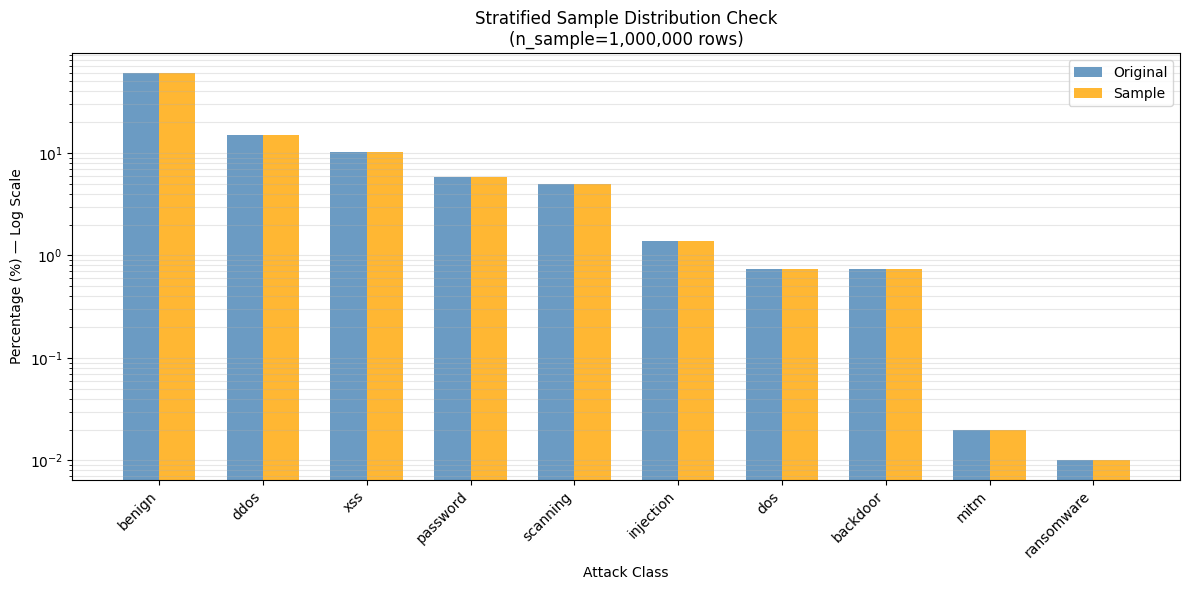

In [ ]:
# Normalize class names to lowercase
df['Attack'] = df['Attack'].str.lower()

# Original distribution 
original = {
    'benign': 61.02,
    'ddos': 15.05,
    'xss': 10.30,
    'password': 5.80,
    'scanning': 4.94,
    'injection': 1.39,
    'dos': 0.74,
    'backdoor': 0.74,
    'mitm': 0.02,
    'ransomware': 0.01,
}

# comparison code
sample_dist = df['Attack'].value_counts(normalize=True) * 100
sample_dist = sample_dist.sort_values(ascending=False)

comparison = pd.DataFrame({
    'Original %': pd.Series(original),
    'Sample %': sample_dist,
})
comparison['Difference'] = (comparison['Sample %'] - comparison['Original %']).round(2)
comparison = comparison.fillna(0).round(2)
comparison = comparison.sort_values('Original %', ascending=False)

print(comparison)

# VERDICT
max_diff = comparison['Difference'].abs().max()
print("-"*70)
if max_diff < 1.0:
    print("EXCELLENT: Distribution matches original (max diff < 1%)")
elif max_diff < 2.0:
    print("GOOD: Distribution matches well (max diff < 2%)")
else:
    print(f"WARNING: Max difference {max_diff:.2f}%")
print("-"*70)

# ===== VISUALIZATION =====
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(comparison))
width = 0.35

ax.bar([i - width/2 for i in x], comparison['Original %'], width, label='Original', alpha=0.8, color='steelblue')
ax.bar([i + width/2 for i in x], comparison['Sample %'], width, label='Sample', alpha=0.8, color='orange')

ax.set_xlabel('Attack Class')
ax.set_ylabel('Percentage (%) — Log Scale')
ax.set_title(f'Stratified Sample Distribution Check\n(n_sample={len(df):,} rows)')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45, ha='right')
ax.set_yscale('log') 
ax.legend()
ax.grid(axis='y', alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [6]:
print("-"*70)
print("NETWORK STRUCTURE — IP Address Diversity")
print("-"*70)

# Unique IP counts
n_src_ips = df['IPV4_SRC_ADDR'].nunique()
n_dst_ips = df['IPV4_DST_ADDR'].nunique()

print(f"\nTotal flows:       {len(df):,}")
print(f"Unique source IPs: {n_src_ips:,}")
print(f"Unique dest IPs:   {n_dst_ips:,}")

# Per-attack IP distribution
print(f"\n{'Attack':<28} {'Unique Src IPs':>15} {'Unique Dst IPs':>15}")
print("─" * 70)

ip_by_attack = (df.groupby('Attack')
                   .agg({'IPV4_SRC_ADDR': 'nunique', 'IPV4_DST_ADDR': 'nunique'})
                   .sort_values('IPV4_SRC_ADDR', ascending=False))

for idx, row in ip_by_attack.iterrows():
    print(f"{idx:<28} {int(row['IPV4_SRC_ADDR']):>15,} {int(row['IPV4_DST_ADDR']):>15,}")

# Top IPs
print(f"\nTop 10 source IPs:")
print(df['IPV4_SRC_ADDR'].value_counts().head(10))

print(f"\nTop 10 dest IPs:")
print(df['IPV4_DST_ADDR'].value_counts().head(10))

----------------------------------------------------------------------
NETWORK STRUCTURE — IP Address Diversity
----------------------------------------------------------------------

Total flows:       1,000,000
Unique source IPs: 712
Unique dest IPs:   1,746

Attack                        Unique Src IPs  Unique Dst IPs
──────────────────────────────────────────────────────────────────────
Benign                                   712           1,683
scanning                                  14             242
password                                   6              15
injection                                  6              15
ddos                                       5              17
Backdoor                                   4               7
xss                                        4              19
dos                                        3              56
ransomware                                 3               3
mitm                                       2             

In [7]:
# Get all unique source IPs sorted
unique_src_ips = sorted(df['IPV4_SRC_ADDR'].unique())

print("="*70)
print(f"ALL UNIQUE SOURCE IPs ({len(unique_src_ips)} total)")
print("="*70)

for ip in unique_src_ips:
    count = (df['IPV4_SRC_ADDR'] == ip).sum()
    pct = count / len(df) * 100
    print(f"{ip:<20} {count:>10,} flows   {pct:>6.2f}%")

ALL UNIQUE SOURCE IPs (712 total)
0.0.0.0                     101 flows     0.01%
0.147.57.10                   1 flows     0.00%
0.43.225.236                  1 flows     0.00%
1.236.239.135                 1 flows     0.00%
1.45.173.173                  1 flows     0.00%
1.85.207.205                  1 flows     0.00%
10.144.33.250                 1 flows     0.00%
10.194.181.147                1 flows     0.00%
100.103.119.132               1 flows     0.00%
100.163.119.209               1 flows     0.00%
100.163.4.40                  1 flows     0.00%
100.19.54.118                 1 flows     0.00%
100.237.57.153                1 flows     0.00%
101.119.11.11                 8 flows     0.00%
101.119.11.16                 1 flows     0.00%
101.119.11.17                 2 flows     0.00%
101.184.145.49                1 flows     0.00%
102.126.207.233               1 flows     0.00%
102.187.218.190               1 flows     0.00%
102.209.47.14                 1 flows     0.00%
102.60

In [8]:
# Count flows per source IP and sort descending
src_ip_counts = df['IPV4_SRC_ADDR'].value_counts()

print("="*70)
print(f"ALL UNIQUE SOURCE IPs ({len(src_ip_counts)} total)")
print("="*70)

for ip, count in src_ip_counts.items():
    pct = count / len(df) * 100
    print(f"{ip:<20} {count:>10,} flows   {pct:>6.2f}%")

ALL UNIQUE SOURCE IPs (712 total)
192.168.1.32            206,004 flows    20.60%
192.168.1.31            192,644 flows    19.26%
192.168.1.30            151,077 flows    15.11%
192.168.1.184           123,355 flows    12.34%
192.168.1.1              68,725 flows     6.87%
192.168.1.35             50,729 flows     5.07%
192.168.1.39             38,675 flows     3.87%
192.168.1.194            35,418 flows     3.54%
192.168.1.152            20,602 flows     2.06%
192.168.1.38             18,424 flows     1.84%
192.168.1.33             16,908 flows     1.69%
192.168.1.193            16,393 flows     1.64%
192.168.1.36             16,337 flows     1.63%
192.168.1.190            12,117 flows     1.21%
192.168.1.195             6,679 flows     0.67%
192.168.1.180             5,129 flows     0.51%
192.168.1.79              4,300 flows     0.43%
192.168.1.34              3,268 flows     0.33%
192.168.1.169             1,790 flows     0.18%
176.28.50.165             1,526 flows     0.15%
52.59.

In [9]:
# Get all unique destination IPs sorted
unique_dst_ips = sorted(df['IPV4_DST_ADDR'].unique())

print("\n" + "="*70)
print(f"ALL UNIQUE DESTINATION IPs ({len(unique_dst_ips)} total)")
print("="*70)

for ip in unique_dst_ips:
    count = (df['IPV4_DST_ADDR'] == ip).sum()
    pct = count / len(df) * 100
    print(f"{ip:<20} {count:>10,} flows   {pct:>6.2f}%")


ALL UNIQUE DESTINATION IPs (1746 total)
0.0.0.0                     101 flows     0.01%
1.135.243.19                  1 flows     0.00%
10.144.33.250                 1 flows     0.00%
10.213.58.86                  1 flows     0.00%
10.26.132.208                 1 flows     0.00%
100.142.10.132                1 flows     0.00%
100.186.248.34                1 flows     0.00%
100.19.54.118                 1 flows     0.00%
101.119.11.10                 2 flows     0.00%
101.119.11.11               330 flows     0.03%
101.119.11.16                86 flows     0.01%
101.119.11.17               250 flows     0.03%
101.119.56.250                1 flows     0.00%
101.141.192.100               1 flows     0.00%
101.168.175.188               1 flows     0.00%
101.85.155.118                1 flows     0.00%
102.145.128.189               2 flows     0.00%
102.44.23.64                  1 flows     0.00%
102.61.203.91                 2 flows     0.00%
102.68.143.63                 1 flows     0.00%

In [10]:
# Count flows per destination IP and sort descending
dst_ip_counts = df['IPV4_DST_ADDR'].value_counts()

print("\n" + "="*70)
print(f"ALL UNIQUE DESTINATION IPs ({len(dst_ip_counts)} total)")
print("="*70)

for ip, count in dst_ip_counts.items():
    pct = count / len(df) * 100
    print(f"{ip:<20} {count:>10,} flows   {pct:>6.2f}%")



ALL UNIQUE DESTINATION IPs (1746 total)
192.168.1.195           106,895 flows    10.69%
192.168.1.184            99,080 flows     9.91%
192.168.1.169            88,930 flows     8.89%
192.168.1.31             88,682 flows     8.87%
192.168.1.190            88,385 flows     8.84%
192.168.1.30             77,781 flows     7.78%
192.168.1.1              76,130 flows     7.61%
192.168.1.152            51,276 flows     5.13%
192.168.1.180            50,004 flows     5.00%
192.168.1.49             40,286 flows     4.03%
192.168.1.194            38,482 flows     3.85%
192.168.1.193            31,618 flows     3.16%
192.168.1.186            20,275 flows     2.03%
192.168.1.46             18,864 flows     1.89%
192.168.1.38             14,711 flows     1.47%
176.28.50.165            14,470 flows     1.45%
192.168.1.79             10,226 flows     1.02%
192.168.1.32              9,863 flows     0.99%
192.168.1.33              6,563 flows     0.66%
52.28.231.150             6,138 flows     0.61%

In [35]:
# Extract subnets (/24) — use correct pandas syntax
df['src_subnet'] = df['IPV4_SRC_ADDR'].str.split('.').str[:3].str.join('.')

# Top 20 subnets by flow count
top_subnets = df['src_subnet'].value_counts().head(20).index.tolist()

print(f"Top subnets:\n{df['src_subnet'].value_counts().head(10)}")

Top subnets:
src_subnet
192.168.1     990398
172.17.0        3509
176.28.50       1526
52.59.177       1493
18.184.104      1066
18.194.169       539
52.28.231        523
0.0.0            101
103.13.80         71
101.119.11        11
Name: count, dtype: int64


ATTACK DISTRIBUTION BY TOP SOURCE SUBNETS
Attack       backdoor  benign    ddos   dos  injection  mitm  password  \
src_subnet                                                               
0.0.0               0     101       0     0          0     0         0   
101.119.11          0      11       0     0          0     0         0   
103.13.80           0      71       0     0          0     0         0   
172.17.0            0    3509       0     0          0     0         0   
172.217.25          0       5       0     0          0     0         0   
176.28.50           0    1526       0     0          0     0         0   
18.184.104          0    1066       0     0          0     0         0   
18.194.169          0     539       0     0          0     0         0   
184.84.165          0       7       0     0          0     0         0   
192.168.1        7390  600574  150480  7393      13873   218     57949   
193.108.91          0       7       0     0          0     0         0

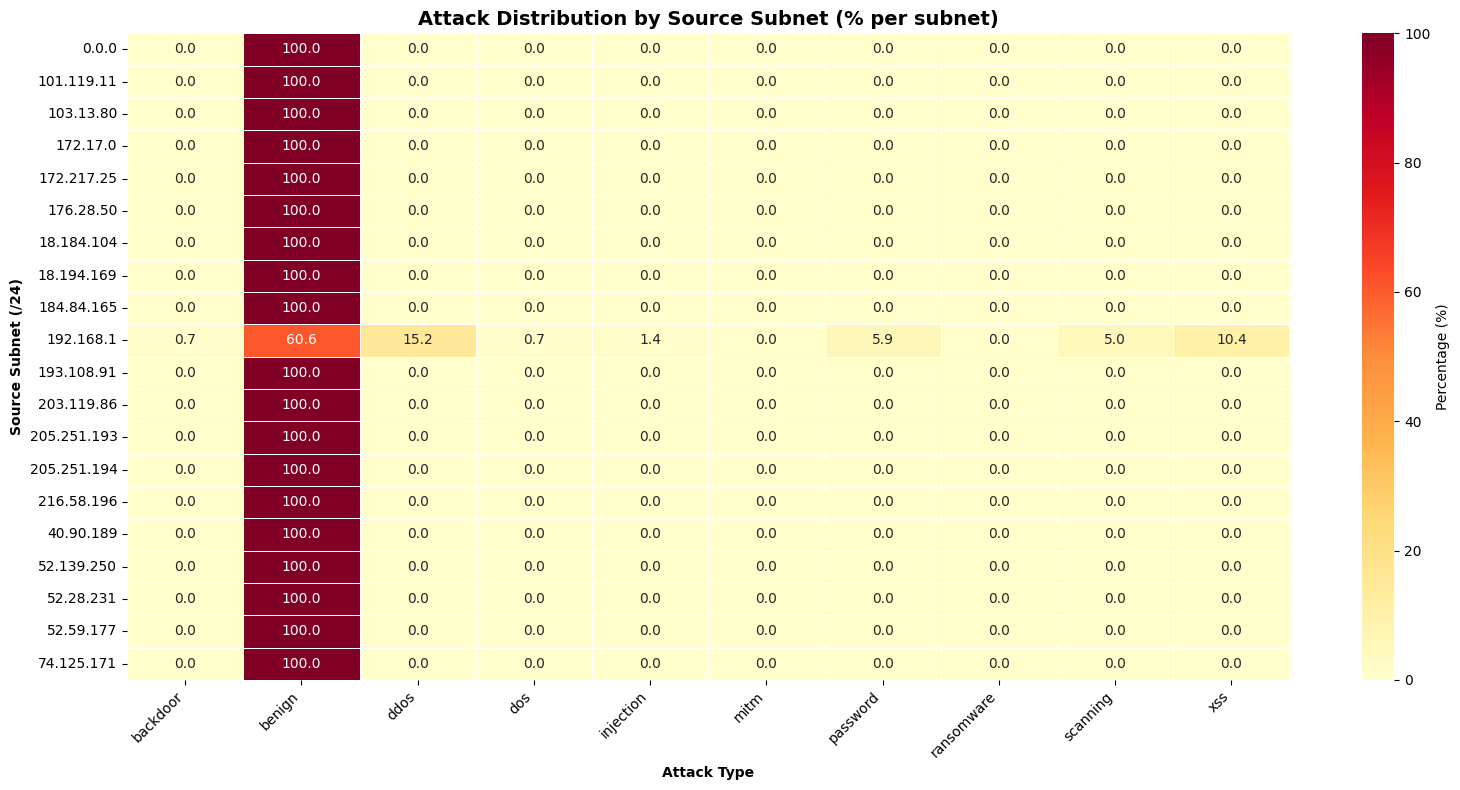

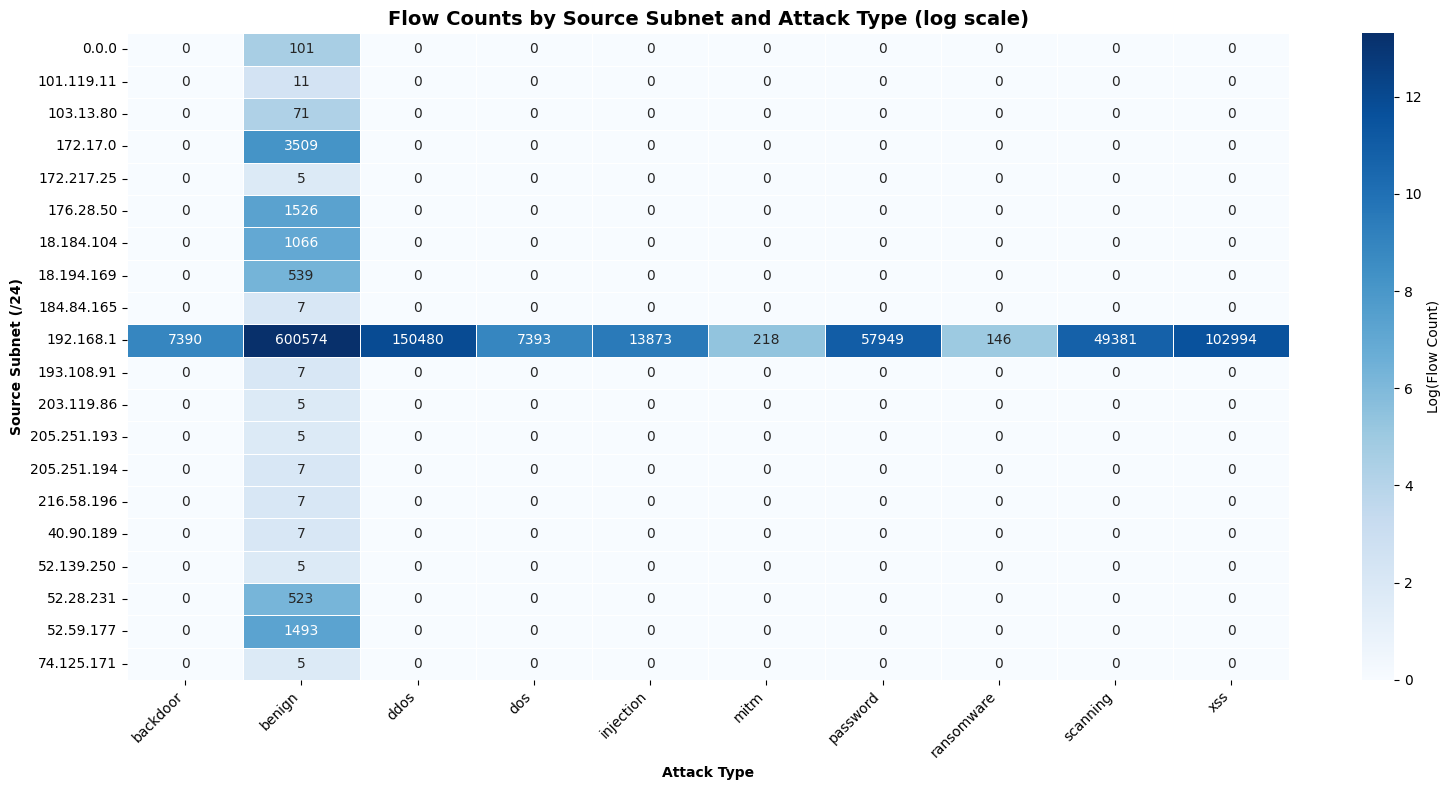

SUMMARY: Top Subnets & Their Attack Profile

192.168.1.0/24
  Total flows: 990,398
  Benign: 600,574 (60.6%)
  Attacks: {'ddos': np.int64(150480), 'xss': np.int64(102994), 'password': np.int64(57949)}

172.17.0.0/24
  Total flows: 3,509
  Benign: 3,509 (100.0%)

176.28.50.0/24
  Total flows: 1,526
  Benign: 1,526 (100.0%)

52.59.177.0/24
  Total flows: 1,493
  Benign: 1,493 (100.0%)

18.184.104.0/24
  Total flows: 1,066
  Benign: 1,066 (100.0%)

18.194.169.0/24
  Total flows: 539
  Benign: 539 (100.0%)

52.28.231.0/24
  Total flows: 523
  Benign: 523 (100.0%)

0.0.0.0/24
  Total flows: 101
  Benign: 101 (100.0%)

103.13.80.0/24
  Total flows: 71
  Benign: 71 (100.0%)

101.119.11.0/24
  Total flows: 11
  Benign: 11 (100.0%)


In [40]:
# ===== Filter to top subnets =====
df_top = df[df['src_subnet'].isin(top_subnets)]

# ===== Cross-tabulation: subnet vs attack =====
cross = df_top.groupby(['src_subnet', 'Attack']).size().unstack(fill_value=0)

# Normalize by row (each subnet = 100%)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

print("="*70)
print("ATTACK DISTRIBUTION BY TOP SOURCE SUBNETS")
print("="*70)
print(cross)
print("\n")

# ===== Heatmap: normalized (%) =====
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(cross_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax, linewidths=0.5)

ax.set_title('Attack Distribution by Source Subnet (% per subnet)', fontweight='bold', fontsize=14)
ax.set_xlabel('Attack Type', fontweight='bold')
ax.set_ylabel('Source Subnet (/24)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ===== Raw counts heatmap (log scale for visibility) =====
fig, ax = plt.subplots(figsize=(16, 8))

# Log scale to see both large and small values
cross_log = np.log1p(cross)

sns.heatmap(cross_log, annot=cross.values, fmt='d', cmap='Blues',
            cbar_kws={'label': 'Log(Flow Count)'}, ax=ax, linewidths=0.5)

ax.set_title('Flow Counts by Source Subnet and Attack Type (log scale)', fontweight='bold', fontsize=14)
ax.set_xlabel('Attack Type', fontweight='bold')
ax.set_ylabel('Source Subnet (/24)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ===== Summary stats =====
print("="*70)
print("SUMMARY: Top Subnets & Their Attack Profile")
print("="*70)
for subnet in top_subnets[:10]:
    subset = df[df['src_subnet'] == subnet]
    total = len(subset)
    benign_count = (subset['Attack'] == 'benign').sum()
    benign_pct = benign_count / total * 100
    
    attack_types = subset[subset['Attack'] != 'benign']['Attack'].value_counts()
    
    print(f"\n{subnet}.0/24")
    print(f"  Total flows: {total:,}")
    print(f"  Benign: {benign_count:,} ({benign_pct:.1f}%)")
    if len(attack_types) > 0:
        print(f"  Attacks: {dict(attack_types.head(3))}")

ATTACK DISTRIBUTION BY TOP DESTINATION SUBNETS
Attack       backdoor      benign       ddos         dos  injection      mitm  \
dst_subnet                                                                      
0.0.0        0.000000  100.000000   0.000000    0.000000   0.000000  0.000000   
101.119.11   0.000000   39.670659   3.143713   23.652695   8.383234  1.946108   
176.28.50    0.000000    5.065653   0.697996    3.317208   3.510712  0.000000   
18.184.104   0.000000    3.239289  12.225705    0.888192  78.996865  0.000000   
18.194.169   0.000000    4.920528   0.000000    0.000000   0.000000  0.000000   
18.195.161   0.000000    0.000000   0.000000  100.000000   0.000000  0.000000   
184.84.165   0.000000   98.013245   0.000000    0.000000   0.000000  0.000000   
192.0.32     0.000000  100.000000   0.000000    0.000000   0.000000  0.000000   
192.168.1    0.794128   63.112259  16.051157    0.668032   1.107755  0.016677   
192.168.35   0.000000   43.843731   0.000000    0.000000   0.0

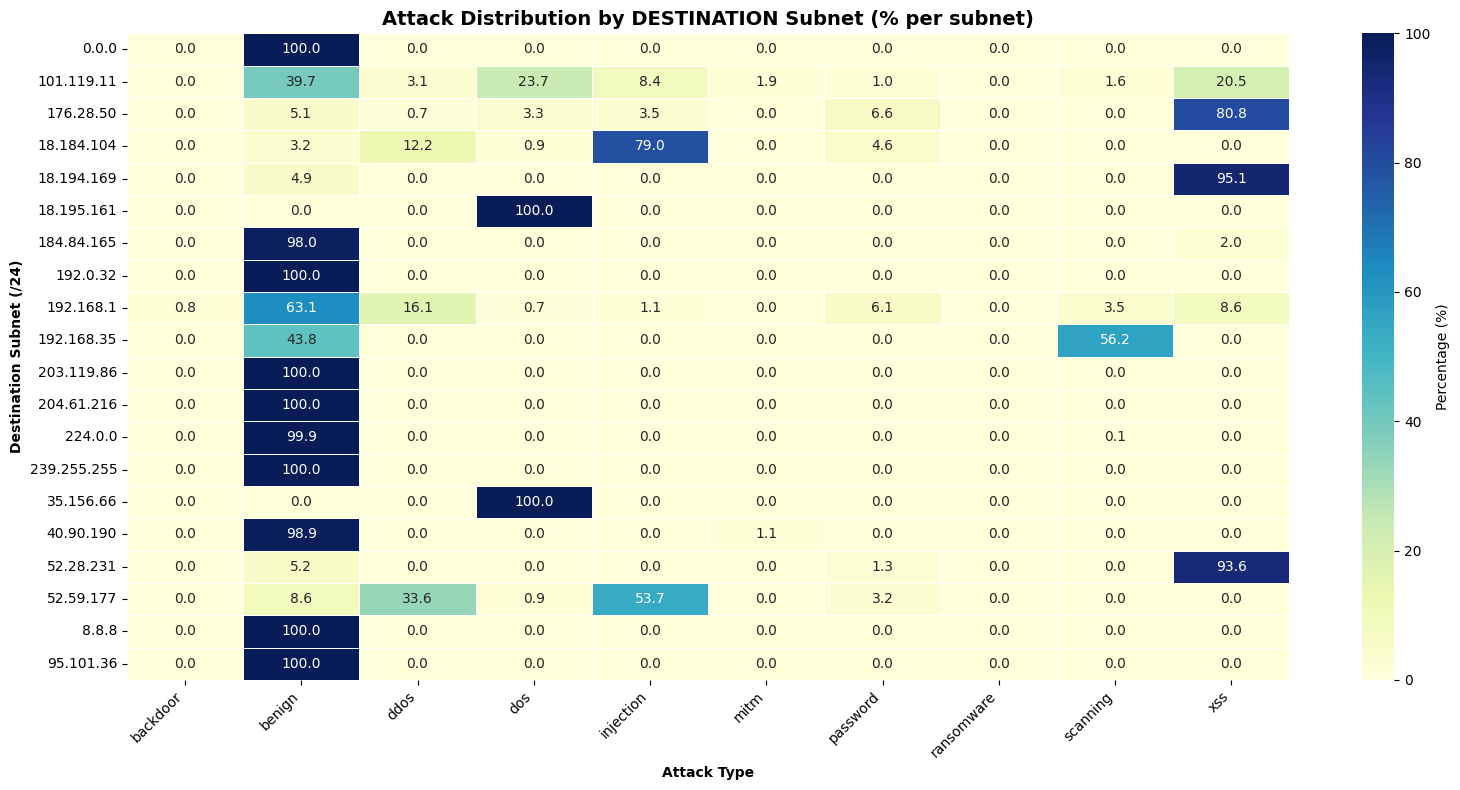

In [41]:
# Extract destination subnets
df['dst_subnet'] = df['IPV4_DST_ADDR'].str.split('.').str[:3].str.join('.')

# Top 20 destination subnets
top_dst_subnets = df['dst_subnet'].value_counts().head(20).index.tolist()

# Cross-tabulation: dst subnet vs attack
df_dst_top = df[df['dst_subnet'].isin(top_dst_subnets)]
cross_dst = df_dst_top.groupby(['dst_subnet', 'Attack']).size().unstack(fill_value=0)
cross_dst_pct = cross_dst.div(cross_dst.sum(axis=1), axis=0) * 100

print("="*70)
print("ATTACK DISTRIBUTION BY TOP DESTINATION SUBNETS")
print("="*70)
print(cross_dst_pct)

# Heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(cross_dst_pct, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax, linewidths=0.5)
ax.set_title('Attack Distribution by DESTINATION Subnet (% per subnet)', fontweight='bold', fontsize=14)
ax.set_xlabel('Attack Type', fontweight='bold')
ax.set_ylabel('Destination Subnet (/24)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Subnet Reference — What Each Network Segment Means

The two heatmaps above group flows by `/24` subnet (first three octets of the IP).
The dataset is a **lab testbed**, so the address space falls into a few functional roles:

| Subnet / Address | Role | Traffic profile |
|---|---|---|
| `192.168.1.0/24` | **Primary internal LAN** — the monitored/victim network where the IoT hosts live | Highly **mixed**: ~63% benign + every attack class (ddos, xss, password, dos, injection, backdoor). This is the network under attack. |
| `192.168.35.0/24` | **Second internal segment** | Mixed: ~44% benign + ~56% **scanning** — this segment is primarily probed/reconnoitred. |
| `172.17.0.0/16` | **Docker bridge network** — containerised services/sensors inside the testbed | Internal service traffic; appears as both source and destination for benign flows. |
| `0.0.0.0` | **Unspecified / placeholder address** (incomplete handshakes, DHCP, malformed flows) | Small count, benign-labelled; safe to treat as noise. |
| `224.0.0.0/4` (e.g. `224.0.0.x`) | **Multicast** — link-local control traffic (IGMP, mDNS, routing) | Effectively 100% benign infrastructure traffic. |
| `239.255.255.x` | **SSDP / UPnP multicast** (device discovery) | Benign infrastructure. |
| `8.8.8.8` | **Google Public DNS** | Benign name resolution. |
| Cloud / CDN ranges (e.g. `18.x`, `52.x`, `40.90.x`, `184.84.x`, `95.101.x`) | **External internet servers** (AWS, Azure, Akamai, etc.) | Mostly **100% benign** when acting as a destination — normal outbound connections. |
| Specific external targets (e.g. `18.195.161` → dos, `52.28.231` → xss, `18.184.104` → injection) | **External hosts that are attack targets/relays** | Each tends to be **single-attack** (one external IP receives one attack type). |
| Hundreds of one-off public IPs (1 flow each) | **Scattered attack sources / internet background** | Appear once; carry the distributed nature of ddos/scanning. |

**Takeaway for partitioning:** heterogeneity lives almost entirely on the **internal
destination subnets** (`192.168.1.*`, `192.168.35.*`). External IPs are nearly
homogeneous (pure benign or a single attack). This is why a **destination-segment**
partition produces meaningfully different clients, while a source-subnet partition does not.

In [42]:
# Destination ports = which services are attacked
port_names = {80:'HTTP',443:'HTTPS',22:'SSH',21:'FTP',53:'DNS',3306:'MySQL',
              445:'SMB',23:'Telnet',3389:'RDP',8080:'HTTP-alt',1883:'MQTT'}
top_ports = df['L4_DST_PORT'].value_counts().head(15)
for port, cnt in top_ports.items():
    svc = port_names.get(port, '—')
    # what attacks hit this port?
    atk = df[df['L4_DST_PORT']==port]['Attack'].value_counts().head(2).to_dict()
    print(f"port {port:<6} {svc:<10} {cnt:>8,} flows   top: {atk}")

port 80     HTTP        205,479 flows   top: {'ddos': 60585, 'xss': 57776}
port 443    HTTPS       100,725 flows   top: {'ddos': 85245, 'scanning': 10430}
port 53     DNS          86,163 flows   top: {'xss': 45210, 'benign': 33133}
port 51642  —            31,946 flows   top: {'benign': 31945, 'scanning': 1}
port 52970  —            13,789 flows   top: {'benign': 13788, 'scanning': 1}
port 57856  —             9,176 flows   top: {'benign': 9174, 'scanning': 2}
port 0      —             9,010 flows   top: {'benign': 9006, 'scanning': 4}
port 21     FTP           7,917 flows   top: {'password': 4866, 'benign': 2899}
port 60899  —             7,843 flows   top: {'benign': 7843}
port 8080   HTTP-alt      5,685 flows   top: {'backdoor': 4423, 'ddos': 762}
port 54674  —             1,650 flows   top: {'benign': 1650}
port 9197   —             1,490 flows   top: {'benign': 1490}
port 22     SSH           1,473 flows   top: {'benign': 1284, 'scanning': 185}
port 15600  —             1,467 flow

In [43]:
for col in ['PROTOCOL', 'L7_PROTO', 'TCP_FLAGS']:
    print(f"\n=== {col} × Attack (top combos) ===")
    ct = df.groupby('Attack')[col].agg(lambda s: s.value_counts().index[0])
    print(ct)   # most common value of col per attack


=== PROTOCOL × Attack (top combos) ===
Attack
backdoor       6
benign         6
ddos           6
dos            6
injection      6
mitm          17
password       6
ransomware     6
scanning       6
xss            6
Name: PROTOCOL, dtype: int64

=== L7_PROTO × Attack (top combos) ===
Attack
backdoor      131
benign          0
ddos           91
dos             5
injection       7
mitm            5
password        7
ransomware     10
scanning        0
xss             7
Name: L7_PROTO, dtype: int64

=== TCP_FLAGS × Attack (top combos) ===
Attack
backdoor      22
benign         2
ddos          18
dos            0
injection     27
mitm           0
password      27
ransomware    31
scanning       2
xss           27
Name: TCP_FLAGS, dtype: int64


In [44]:
vol = ['IN_BYTES','OUT_BYTES','IN_PKTS','OUT_PKTS','FLOW_DURATION_MILLISECONDS']
print(df.groupby('Attack')[vol].median())     # median per class — robust to outliers
print("\nSkew:\n", df[vol].skew())  

            IN_BYTES  OUT_BYTES  IN_PKTS  OUT_PKTS  FLOW_DURATION_MILLISECONDS
Attack                                                                        
backdoor       288.0      240.0      6.0       6.0                      1501.0
benign          52.0        0.0      1.0       0.0                         1.0
ddos           112.0       60.0      2.0       1.0                         1.0
dos           3720.0       81.0     93.0       1.0                       152.0
injection      512.0     2239.0      5.0       6.0                       292.0
mitm           140.0      258.0      2.0       1.0                        39.0
password       415.0      921.0      5.0       5.0                        20.0
ransomware    2862.0      204.0      7.0       4.0                        33.5
scanning        44.0        0.0      1.0       0.0                         1.0
xss            573.0      334.0      5.0       4.0                        26.0

Skew:
 IN_BYTES                      289.462879
OUT